Dataset path: /home/ubuntu/NeiroNetwork/MyNN/DS_EURUSD/DS_IN/dataset_EURUSD_M5.csv
Первые строки датасета:
                 Time  Target1  Target2      M5_CCI  M5_CCI_lag1  M5_CCI_lag3  \
0 2018-01-02 05:20:00     -1.0     -1.0  133.718347    79.353766    18.279990   
1 2018-01-02 05:25:00     -1.0     -1.0  158.569834   133.718347    47.664342   
2 2018-01-02 05:30:00     -1.0     -1.0  133.239477   158.569834    79.353766   
3 2018-01-02 05:35:00     -1.0     -1.0  107.521368   133.239477   133.718347   
4 2018-01-02 05:40:00     -1.0     -1.0  106.852276   107.521368   158.569834   

      M5_RSI  M5_RSI_lag1  M5_RSI_lag3  M5_StochMain  ...  M5_Ret_4  M5_Ret_8  \
0  63.991378    60.012315    57.617696     91.194969  ...  0.000758  0.000849   
1  64.847513    63.991378    54.493966     96.348315  ...  0.000350  0.001033   
2  61.389418    64.847513    60.012315     92.287918  ...  0.000350  0.000808   
3  60.133640    61.389418    63.991378     87.468672  ...  0.000100  0.000766   
4

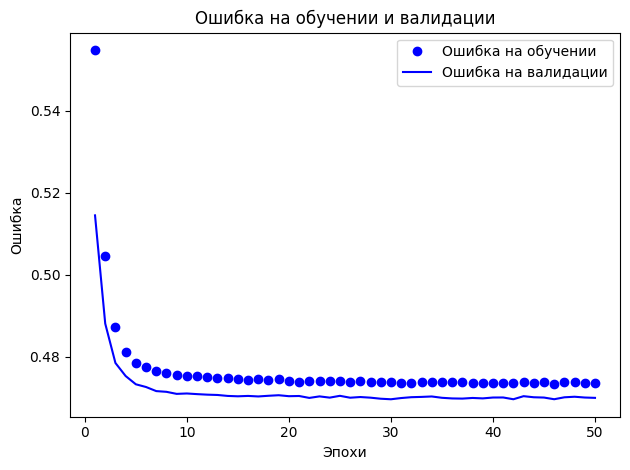

In [ ]:
import main

history = main.main()
main.plot_training_history(history)

In [ ]:
print(type(main.model))
#print(my_models)
main.model.save("exports/model.keras")
main.model.save("exports/saved_model")

<class 'keras.engine.sequential.Sequential'>


INFO:tensorflow:Assets written to: exports/saved_model/assets


In [ ]:
import tf2onnx
import os
os.environ["PROTOCOL_BUFFERS_PYTHON_IMPLEMENTATION"] = "python"


In [ ]:
!python -m tf2onnx.convert --saved-model exports/saved_model --output exports/model.onnx --opset 17

2026-06-26 21:57:50,879 - WARNING - ***IMPORTANT*** Installed protobuf is not cpp accelerated. Conversion will be extremely slow. See https://github.com/onnx/tensorflow-onnx/issues/1557
2026-06-26 21:57:50,880 - WARNING - '--tag' not specified for saved_model. Using --tag serve
2026-06-26 21:57:51,878 - INFO - Signatures found in model: [serving_default].
2026-06-26 21:57:51,878 - WARNING - '--signature_def' not specified, using first signature: serving_default
2026-06-26 21:57:51,878 - INFO - Output names: ['dense_3']
2026-06-26 21:57:51.885547: I tensorflow/core/grappler/devices.cc:75] Number of eligible GPUs (core count >= 8, compute capability >= 0.0): 0 (Note: TensorFlow was not compiled with CUDA or ROCm support)
2026-06-26 21:57:51.885746: I tensorflow/core/grappler/clusters/single_machine.cc:358] Starting new session
2026-06-26 21:57:52.002639: I tensorflow/core/grappler/devices.cc:75] Number of eligible GPUs (core count >= 8, compute capability >= 0.0): 0 (Note: TensorFlow was

In [ ]:
import onnxruntime as ort
import numpy as np

session = ort.InferenceSession("exports/model.onnx")

input_name = session.get_inputs()[0].name
output_name = session.get_outputs()[0].name

x_sample = main.X_test[:10].astype(np.float32)

keras_pred = main.model.predict(x_sample, verbose=0)
onnx_pred = session.run([output_name], {input_name: x_sample})[0]

print(keras_pred.ravel())
print(onnx_pred.ravel())
print(np.max(np.abs(keras_pred - onnx_pred)))

[-0.62763745 -0.26856884 -0.54438734  0.5016486  -0.6444591   0.4264367
  0.27073255 -0.6390345   0.60050905 -0.6753732 ]
[-0.6276375  -0.2685689  -0.5443874   0.5016486  -0.6444592   0.42643666
  0.27073255 -0.63903445  0.6005091  -0.67537314]
5.9604645e-08


In [ ]:
import numpy as np

# Прогнозы на всём тестовом множестве
pred = main.model.predict(main.X_test, verbose=0).ravel()
y    = main.y_test

# Убираем случаи где таргет == 0 (NoTrade): модель не обязана их угадывать
mask_trade = (y != 0)
pred_trade = pred[mask_trade]
y_trade    = y[mask_trade]

# Модель даёт сигнал только там, где она уверена (|pred| > порог)
# Попробуем несколько порогов
print(f"Всего тестовых баров:              {len(y)}")
print(f"  из них Trade (±1):               {mask_trade.sum()}")
print(f"  из них NoTrade (0):              {(~mask_trade).sum()}")
print()
print(f"{'Порог':>6}  {'Сигналов':>9}  {'% охвата':>9}  {'Win rate':>9}")
print("-" * 42)
for thresh in [0.0, 0.1, 0.2, 0.3, 0.4, 0.5]:
    # Берём только бары, где |pred| > порога (и таргет != 0)
    mask_conf = (np.abs(pred_trade) > thresh)
    n = mask_conf.sum()
    if n == 0:
        continue
    p = pred_trade[mask_conf]
    t = y_trade[mask_conf]
    # Победа: знак прогноза совпадает со знаком таргета
    wins = ((p > 0) & (t > 0)) | ((p < 0) & (t < 0))
    wr = wins.sum() / n * 100
    coverage = n / mask_trade.sum() * 100
    print(f"  {thresh:.1f}  {n:>9}  {coverage:>8.1f}%  {wr:>8.1f}%")


Всего тестовых баров:              124761
  из них Trade (±1):               77127
  из них NoTrade (0):              47634

 Порог   Сигналов   % охвата   Win rate
------------------------------------------
  0.0      77127     100.0%      75.0%
  0.1      62212      80.7%      80.2%
  0.2      48424      62.8%      85.4%
  0.3      36342      47.1%      90.6%
  0.4      26421      34.3%      95.4%
  0.5      19036      24.7%      98.6%
